In [86]:
import warnings
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from category_encoders import OneHotEncoder
from IPython.display import VimeoVideo
from sklearn.linear_model import LinearRegression, Ridge  # noqa F401
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

In [87]:
def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath)

    # Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]

    # Subset data: Remove outliers for "surface_covered_in_m2"
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area]

    # Split "lat-lon" column
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)
    
    #Extract Neighbourhood
    df["neighbourhood"] = df["place_with_parent_names"].str.split("|",expand=True)[3]
    df.drop(columns=["place_with_parent_names"],inplace=True);

    

    return df

In [88]:
files = glob("data/buenos-aires-real-estate-*.csv")
files

['data/buenos-aires-real-estate-3.csv',
 'data/buenos-aires-real-estate-2.csv',
 'data/buenos-aires-real-estate-1.csv',
 'data/buenos-aires-real-estate-5.csv',
 'data/buenos-aires-real-estate-4.csv']

In [89]:
assert len(files) == 5, f"`files` should contain 5 items, not {len(files)}"

In [90]:
frames = []
for file in files: 
    df = wrangle(file);
    frames.append(df);


In [91]:
type(frames[0])

pandas.core.frame.DataFrame

In [92]:
# Check your work
assert len(frames) == 5, f"`frames` should contain 5 items, not {len(frames)}"
assert all(
    [isinstance(frame, pd.DataFrame) for frame in frames]
), "The items in `frames` should all be DataFrames."

In [93]:
df = pd.concat(frames,ignore_index=True)
df.head()

,operation,property_type,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,lat,lon,neighbourhood
0,sell,apartment,120000.0,USD,1819488.00,120000.0,NaN,55.0,NaN,2181.818182,NaN,2.0,NaN,http://villa-general-mitre.properati.com.ar/xx...,-34.616004,-58.470506,Villa General Mitre
1,sell,apartment,89000.0,USD,1349453.60,89000.0,NaN,37.0,NaN,2405.405405,7.0,2.0,NaN,http://palermo.properati.com.ar/ya5i_venta_dep...,-34.584712,-58.444927,Palermo
2,sell,apartment,183495.0,USD,2782224.58,183495.0,92.0,57.0,1994.51087,3219.210526,NaN,2.0,NaN,http://saavedra.properati.com.ar/12izq_venta_d...,-34.554652,-58.493644,Saavedra
3,sell,apartment,95000.0,USD,1440428.00,95000.0,53.0,47.0,1792.45283,2021.276596,NaN,2.0,NaN,http://villa-del-parque.properati.com.ar/wy0n_...,-34.610581,-58.479625,Villa del Parque
4,sell,apartment,95000.0,USD,1440428.00,95000.0,0.0,35.0,NaN,2714.285714,NaN,1.0,NaN,http://belgrano.properati.com.ar/xw9a_venta_de...,-34.558227,-58.458357,Belgrano


In [94]:
df.shape

(6582, 17)

In [95]:
# Check your work
assert len(df) == 6582, f"`df` is the wrong size: {len(df)}."

In [96]:
#Test Cell on how to extract neighbourhood and delete the place with parent names
#df["neighbourhood"] = df["place_with_parent_names"].str.split("|",expand=True)[3]
#df.drop(columns=["place_with_parent_names"],inplace=True);

In [97]:
frames[0]

,operation,property_type,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,lat,lon,neighbourhood
7,sell,apartment,120000.0,USD,1819488.00,120000.0,NaN,55.0,NaN,2181.818182,NaN,2.0,NaN,http://villa-general-mitre.properati.com.ar/xx...,-34.616004,-58.470506,Villa General Mitre
20,sell,apartment,89000.0,USD,1349453.60,89000.0,NaN,37.0,NaN,2405.405405,7.0,2.0,NaN,http://palermo.properati.com.ar/ya5i_venta_dep...,-34.584712,-58.444927,Palermo
21,sell,apartment,183495.0,USD,2782224.58,183495.0,92.0,57.0,1994.510870,3219.210526,NaN,2.0,NaN,http://saavedra.properati.com.ar/12izq_venta_d...,-34.554652,-58.493644,Saavedra
41,sell,apartment,95000.0,USD,1440428.00,95000.0,53.0,47.0,1792.452830,2021.276596,NaN,2.0,NaN,http://villa-del-parque.properati.com.ar/wy0n_...,-34.610581,-58.479625,Villa del Parque
43,sell,apartment,95000.0,USD,1440428.00,95000.0,0.0,35.0,NaN,2714.285714,NaN,1.0,NaN,http://belgrano.properati.com.ar/xw9a_venta_de...,-34.558227,-58.458357,Belgrano
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8574,sell,apartment,145000.0,USD,2198548.00,145000.0,50.0,50.0,2900.000000,2900.000000,NaN,NaN,NaN,http://belgrano.properati.com.ar/e4x0_venta_de...,-34.553534,-58.436914,Belgrano
8577,sell,apartment,149000.0,USD,2259197.60,149000.0,53.0,50.0,2811.320755,2980.000000,NaN,NaN,NaN,http://recoleta.properati.com.ar/11a35_venta_d...,-34.583538,-58.405318,Recoleta
8582,sell,apartment,118000.0,USD,1789163.20,118000.0,40.0,40.0,2950.000000,2950.000000,NaN,2.0,1790.0,http://belgrano.properati.com.ar/zugq_venta_de...,-34.568917,-58.457627,Belgrano
8593,sell,apartment,77800.0,USD,1179634.72,77800.0,NaN,36.0,NaN,2161.111111,NaN,2.0,NaN,http://san-cristobal.properati.com.ar/1164k_ve...,-34.622790,-58.394566,San Cristobal


In [99]:
df.rename(columns={"neighbourhood": "neighborhood"}, inplace=True)

In [100]:
target = "price_aprox_usd"
features = ["neighborhood"]
y_train = df[target]
X_train = df[features]

In [101]:
# Check your work
assert X_train.shape == (6582, 1), f"`X_train` is the wrong size: {X_train.shape}."
assert y_train.shape == (6582,), f"`y_train` is the wrong size: {y_train.shape}."

In [102]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)
print("Mean apt price:", y_mean);

print("Baseline MAE:", mean_absolute_error(y_train,y_pred_baseline))

Mean apt price: 132383.83701458524
Baseline MAE: 44860.10834274133


In [127]:
# Trying Linear Regression
model = Ridge();
model.fit(X_train,y_train);

ValueError: could not convert string to float: 'Villa General Mitre'

In [128]:
# Instantiate
ohe = OneHotEncoder(use_cat_names=True);

# Fit
ohe.fit(X_train)

XT_train = ohe.transform(X_train);
print(XT_train.shape)
XT_train.head()

(6582, 57)


,neighborhood_Villa General Mitre,neighborhood_Palermo,neighborhood_Saavedra,neighborhood_Villa del Parque,neighborhood_Belgrano,neighborhood_Coghlan,neighborhood_Chacarita,neighborhood_Boedo,neighborhood_Caballito,neighborhood_Monserrat,...,neighborhood_Versalles,neighborhood_Villa Lugano,neighborhood_Parque Avellaneda,neighborhood_Las Cañitas,neighborhood_Villa Soldati,neighborhood_Parque Chas,neighborhood_Velez Sarsfield,neighborhood_Pompeya,neighborhood_Villa Real,neighborhood_Catalinas
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


One Hot Encoding on all features so as to encode categorical data into numbers..later we'll do this using pipeline

In [129]:
# Check your work
assert XT_train.shape == (6582, 57), f"`XT_train` is the wrong shape: {XT_train.shape}"

In [137]:
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    Ridge()
)
model.fit(X_train,y_train);

In [138]:
# Check your work
check_is_fitted(model[-1])

In [139]:
y_pred_training = model.predict(X_train);
mae_training = mean_absolute_error(y_train,y_pred_training);
print("Training MAE:", round(mae_training, 2))

Training MAE: 39350.22


In [140]:
X_test = pd.read_csv("data/buenos-aires-test-features.csv")[features]
y_pred_test = pd.Series(model.predict(X_test))
y_pred_test.head()

0    246624.694624
1    161355.968734
2     98232.051308
3    110846.030377
4    127777.538197
dtype: float64

MAE of test was very high 
5639294837355918.0. You can do better. Try to beat 45000. If your test MAE is a lot bigger than your training MAE, the issue may be overfitting.
This was solved using ridget in second iteration

In [141]:
intercept = model.named_steps["ridge"].intercept_
coefficients = model.named_steps["ridge"].coef_
print("coefficients len:", len(coefficients))
print(coefficients[:5])  # First five coefficients

coefficients len: 57
[  7714.62159939  45934.4105851   14701.16243686 -12595.50084744
  46954.20800905]


In [142]:
# Check your work
assert isinstance(
    intercept, float
), f"`intercept` should be a `float`, not {type(intercept)}."
assert isinstance(
    coefficients, np.ndarray
), f"`coefficients` should be a `float`, not {type(coefficients)}."
assert coefficients.shape == (
    57,
), f"`coefficients` is wrong shape: {coefficients.shape}."

In [143]:
feature_names = model.named_steps["onehotencoder"].get_feature_names()
print("features len:", len(feature_names))
print(feature_names[:5])  # First five feature names

features len: 57
['neighborhood_Villa General Mitre' 'neighborhood_Palermo'
 'neighborhood_Saavedra' 'neighborhood_Villa del Parque'
 'neighborhood_Belgrano']


In [144]:
# Check your work
assert isinstance(
    feature_names, np.ndarray
), f"`features` should be a `list`, not {type(feature_names)}."
assert len(feature_names) == len(
    coefficients
), "You should have the same number of features and coefficients."

In [145]:
feat_imp = pd.Series(coefficients,index=feature_names)
feat_imp.head()


neighborhood_Villa General Mitre     7714.621599
neighborhood_Palermo                45934.410585
neighborhood_Saavedra               14701.162437
neighborhood_Villa del Parque      -12595.500847
neighborhood_Belgrano               46954.208009
dtype: float64

In [146]:
# Check your work
assert isinstance(
    feat_imp, pd.Series
), f"`feat_imp` should be a `float`, not {type(feat_imp)}."
assert feat_imp.shape == (57,), f"`feat_imp` is wrong shape: {feat_imp.shape}."
assert all(
    a == b for a, b in zip(sorted(feature_names), sorted(feat_imp.index))
), "The index of `feat_imp` should be identical to `features`."

In [147]:
print(f"price = {intercept.round(2)}")
for f, c in feat_imp.items():
    print(f"+ ({round(c, 2)} * {f})")

price = 118524.65
+ (7714.62 * neighborhood_Villa General Mitre)
+ (45934.41 * neighborhood_Palermo)
+ (14701.16 * neighborhood_Saavedra)
+ (-12595.5 * neighborhood_Villa del Parque)
+ (46954.21 * neighborhood_Belgrano)
+ (12223.11 * neighborhood_Coghlan)
+ (-2898.96 * neighborhood_Chacarita)
+ (-6837.4 * neighborhood_Boedo)
+ (9252.89 * neighborhood_Caballito)
+ (-20292.6 * neighborhood_Monserrat)
+ (-7905.29 * neighborhood_Centro / Microcentro)
+ (42831.32 * neighborhood_Nuñez)
+ (-11172.55 * neighborhood_Balvanera)
+ (5638.47 * neighborhood_San Telmo)
+ (2903.34 * neighborhood_Almagro)
+ (55590.93 * neighborhood_Barrio Norte)
+ (-3427.44 * neighborhood_Monte Castro)
+ (72740.78 * neighborhood_Recoleta)
+ (-21078.78 * neighborhood_Mataderos)
+ (12671.71 * neighborhood_Villa Urquiza)
+ (-15807.01 * neighborhood_Parque Patricios)
+ (-8662.28 * neighborhood_Flores)
+ (-28353.36 * neighborhood_Boca)
+ (-14088.02 * neighborhood_Floresta)
+ (-10678.63 * neighborhood_San Cristobal)
+ (6277.

Now we go back to the linearRegression model and change it to Ridge model as Ridge add a regularization to penalize the high values of coefficients

In [148]:
# Check your work
assert isinstance(
    model[-1], Ridge
), "Did you retrain your model using a `Ridge` predictor?"

Text(0.5, 1.0, 'Feature Importance for Apartment Price')

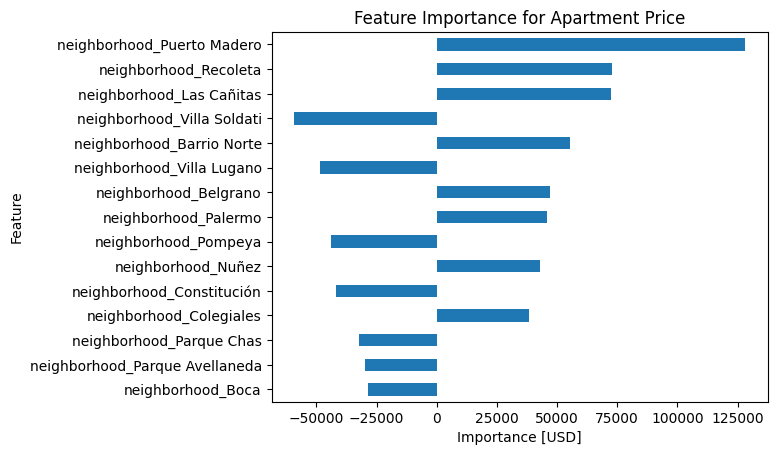

In [149]:
feat_imp.sort_values(key=abs).tail(15).plot(kind="barh")
plt.xlabel("Importance [USD]")
plt.ylabel("Feature")
plt.title("Feature Importance for Apartment Price")